In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

from models.timeseries import load_training_df

from datetime import datetime, timedelta
from seaborn import set_style
set_style("whitegrid")

In [2]:
daily = load_training_df()

## Using StatsForecast

In [3]:
from statsforecast import StatsForecast
from statsforecast.models import (
    AutoARIMA,
    HoltWinters,
    CrostonClassic as Croston, 
    HistoricAverage,
    DynamicOptimizedTheta as DOT,
    SeasonalNaive
)

from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import r2_score

In [4]:
sf_daily = pd.DataFrame()
sf_daily['y'] = daily['Wind']
sf_daily['ds'] = daily.index
sf_daily['unique_id'] = 'A'

sf_train = sf_daily.query('ds<2022')
sf_test = sf_daily.query('ds>2022')

In [5]:
models = [
    AutoARIMA(),
    # HoltWinters(),
    # Croston(),
    # SeasonalNaive(season_length=365),
    HistoricAverage(),
    # DOT(season_length=365)
]
modelnames = []
for m in models:
    modelnames.append(str(m))

AutoARIMA MAPE:  0.7318260065236728
HistoricAverage MAPE:  0.8291258939361777


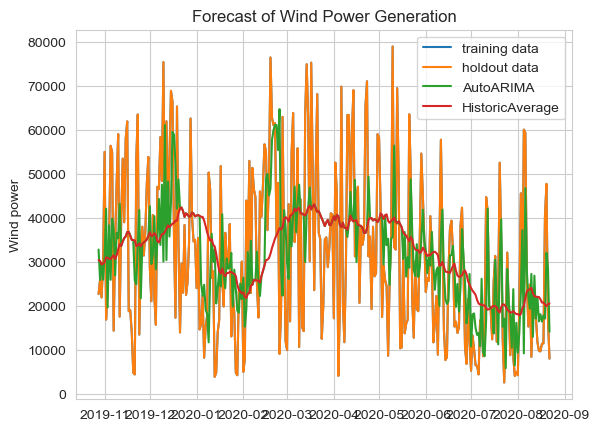

In [6]:
horizon = 1
level = [90]

mses = {}
mapes = {}
predictions = {}
for m in modelnames:
    mses[m] = []
    mapes[m] = []
    predictions[m] = []
for i in range(300, 600):
    tt = sf_daily.iloc[i-30:i]
    sf = StatsForecast(models=models, freq='D', n_jobs=-1,)
    forecasts_df = sf.forecast(df=tt, h=horizon, level=level)
    for m in modelnames:
        predictions[m].append(forecasts_df[m].values)
        mses[m].append(mse(np.array(sf_daily.iloc[i][['y']]), forecasts_df[m].values))
        mapes[m].append(mape(np.array(sf_daily.iloc[i][['y']]), forecasts_df[m].values))
plt.plot(sf_daily.index[300:600], sf_daily.y.iloc[300:600], label = 'training data')
plt.plot(sf_daily.index[300:600], sf_daily.y.iloc[300:600], label = 'holdout data')
for m in modelnames:
    plt.plot(sf_daily.index[300:600], predictions[m], label = m)
    print(f'{m} MAPE: ', np.mean(mapes[m]))    

plt.title("Forecast of Wind Power Generation")
plt.ylabel('Wind power')
plt.legend()
plt.show()


AutoARIMA MAPE:  0.7489943887139845
HistoricAverage MAPE:  0.8068197775015398


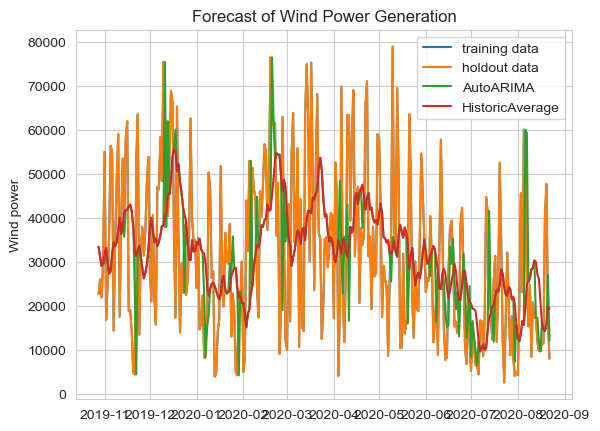

In [ ]:
horizon = 1
level = [90]

mses = {}
mapes = {}
predictions = {}
for m in modelnames:
    mses[m] = []
    mapes[m] = []
    predictions[m] = []
for i in range(300, 600):
    tt = sf_daily.iloc[i-10:i]
    sf = StatsForecast(models=models, freq='D', n_jobs=-1,)
    forecasts_df = sf.forecast(df=tt, h=horizon, level=level)
    for m in modelnames:
        predictions[m].append(forecasts_df[m].values)
        mses[m].append(mse(np.array(sf_daily.iloc[i][['y']]), forecasts_df[m].values))
        mapes[m].append(mape(np.array(sf_daily.iloc[i][['y']]), forecasts_df[m].values))
plt.plot(sf_daily.index[300:600], sf_daily.y.iloc[300:600], label = 'training data')
plt.plot(sf_daily.index[300:600], sf_daily.y.iloc[300:600], label = 'holdout data')
for m in modelnames:
    plt.plot(sf_daily.index[300:600], predictions[m], label = m)
    print(f'{m} MAPE: ', np.mean(mapes[m]))   
    print(f'{m} r2 ', r2_score(sf_daily.iloc[300:600].y, predictions['AutoARIMA'])) 

plt.title("Forecast of Wind Power Generation")
plt.ylabel('Wind power')
plt.legend()
plt.show()


# ARIMAx

In [7]:
from statsforecast.models import AutoARIMA
from statsforecast import StatsForecast

from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_percentage_error as mape


In [ ]:
sf_daily = pd.DataFrame()
sf_daily['ds'] = daily.index
sf_daily['unique_id'] = 'A'
sf_daily['y'] = daily['Wind'].values
sf_daily['windspeed'] = daily['mean_windspeed'].values

sf_train = sf_daily.query('ds<2021')
sf_test = sf_daily.query('ds>2021')

sf_train.head()

,ds,unique_id,y,windspeed
0,2019-01-01,A,52554.0,18.808882
1,2019-01-02,A,38859.0,14.186294
2,2019-01-03,A,18209.0,9.101206
3,2019-01-04,A,31732.0,14.528947
4,2019-01-05,A,4615.0,6.905592


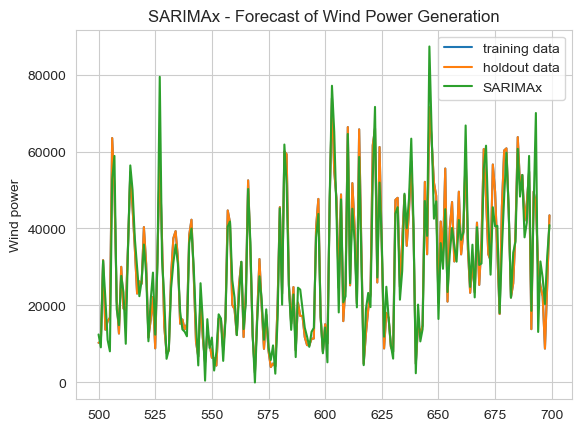

MAPE:  0.1805767162216447
r2  0.9055316682201349


In [ ]:
horizon = 1
level = [90]

forecast30 = []
mses30 = []
mape30 = []
models = [AutoARIMA(season_length=365)]

for i in range(500, 700):
    sfm30 = StatsForecast(models=models, freq='D', n_jobs=-1,)
    fcst = sfm30.forecast(df=sf_train.iloc[i-30:i], h=horizon, X_df=sf_train.drop(columns='y').iloc[i:i+1], level=level)
    forecast30.append(fcst.AutoARIMA.values)
    mses30.append(mse(np.array(sf_train.iloc[i][['y']]), fcst.AutoARIMA.values))
    mape30.append(mape(np.array(sf_train.iloc[i][['y']]), fcst.AutoARIMA.values))

plt.plot(sf_train.index[500:700], sf_train.y.iloc[500:700], label = 'training data')
plt.plot(sf_train.index[500:700], sf_train.y.iloc[500:700], label = 'holdout data')
plt.plot(sf_train.index[500:700], forecast30, label = 'ARIMAx')

plt.title("ARIMAx - Forecast of Wind Power Generation")
plt.ylabel('Wind power')
plt.legend()
plt.show()
print('MAPE: ', np.mean(mape30))  
print('r2 ', r2_score(sf_train.iloc[500:700].y, forecast30))  



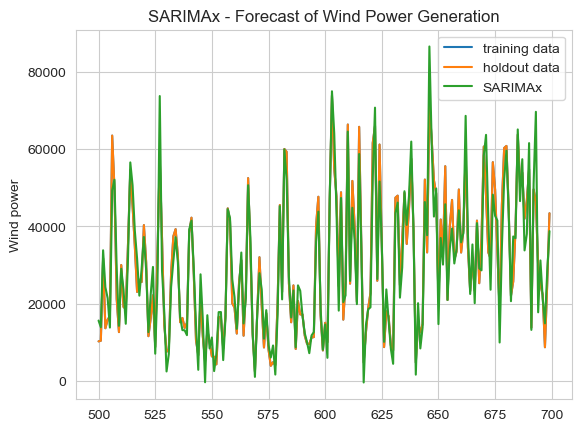

MAPE:  0.1799158655183454
r2  0.9111664813684702


In [ ]:
horizon = 1
level = [90]

forecast60 = []
mses60 = []
mape60 = []
models = [AutoARIMA()]

for i in range(500, 700):
    sfm60 = StatsForecast(models=models, freq='D', n_jobs=-1,)
    fcst = sfm60.forecast(df=sf_train.iloc[i-60:i], h=horizon, X_df=sf_train.drop(columns='y').iloc[i:i+1], level=level)
    forecast60.append(fcst.AutoARIMA.values)
    mses60.append(mse(np.array(sf_train.iloc[i][['y']]), fcst.AutoARIMA.values))
    mape60.append(mape(np.array(sf_train.iloc[i][['y']]), fcst.AutoARIMA.values))

plt.plot(sf_train.index[500:700], sf_train.y.iloc[500:700], label = 'training data')
plt.plot(sf_train.index[500:700], sf_train.y.iloc[500:700], label = 'holdout data')
plt.plot(sf_train.index[500:700], forecast60, label = 'ARIMAx')

plt.title("ARIMAx - Forecast of Wind Power Generation")
plt.ylabel('Wind power')
plt.legend()
plt.show()
print('MAPE: ', np.mean(mape60))  
print('r2 ', r2_score(sf_train.iloc[500:700].y, forecast60))  



/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsforecast/arima.py:1153: UserWarning: xreg not required by this model, ignoring the provided regressors
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsforecast/arima.py:1153: UserWarning: xreg not required by this model, ignoring the provided regressors
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsforecast/arima.py:1153: UserWarning: xreg not required by this model, ignoring the provided regressors
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsforecast/arima.py:1153: UserWarning: xreg not required by this model, ignoring the provided regressors
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsforecast/arima.py:1153: UserWarning: xreg not required by this model, ignoring the provide

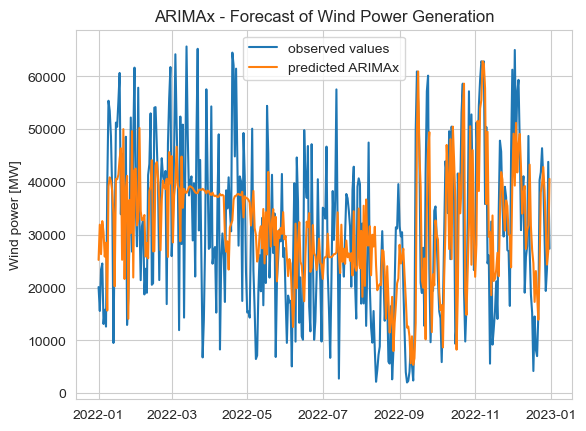

MAPE:  0.6611283189030598
r2  0.19144742904445478


In [8]:
horizon = 1
level = [90]

forecast60 = []
mape60 = []
models = [AutoARIMA()]

for date in pd.date_range(start='2022-01-01', end='2022-12-31', freq='D'):
    sfm60 = StatsForecast(models=models, freq='D', n_jobs=-1,)
    fcst = sfm60.forecast(df=sf_daily[(sf_daily['ds'] < date) & (sf_daily['ds']> (date - pd.Timedelta(days=61)))], h=horizon, X_df=sf_daily.drop(columns='y')[sf_daily['ds'] == date], level=level)
    forecast60.append(fcst.AutoARIMA.values)

plt.plot(sf_daily[(sf_daily['ds']>'2021-12-31') & (sf_daily['ds']<'2023-01-01')].ds, sf_daily[(sf_daily['ds']>'2021-12-31') & (sf_daily['ds']<'2023-01-01')].y, label = 'observed values')
plt.plot(sf_daily[(sf_daily['ds']>'2021-12-31') & (sf_daily['ds']<'2023-01-01')].ds, forecast60, label = 'predicted ARIMAx')
plt.title("ARIMAx - Forecast of Wind Power Generation")
plt.ylabel('Wind power [MW]')
plt.legend()
plt.show()

print('MAPE: ', mape(sf_daily[(sf_daily['ds']>'2021-12-31') & (sf_daily['ds']<'2023-01-01')].y.values, forecast60))  
print('r2 ', r2_score(sf_daily[(sf_daily['ds']>'2021-12-31') & (sf_daily['ds']<'2023-01-01')].y.values, forecast60))  



# 2022 validation data

In [10]:
from models.timeseries import ARIMAxPredictions

Mean absolute percentage error:  0.2053058585276839
Mean absolute error:  4458.350353054218
r2 score:  0.8514288333055781


(0.2053058585276839, 4458.350353054218, 0.8514288333055781)

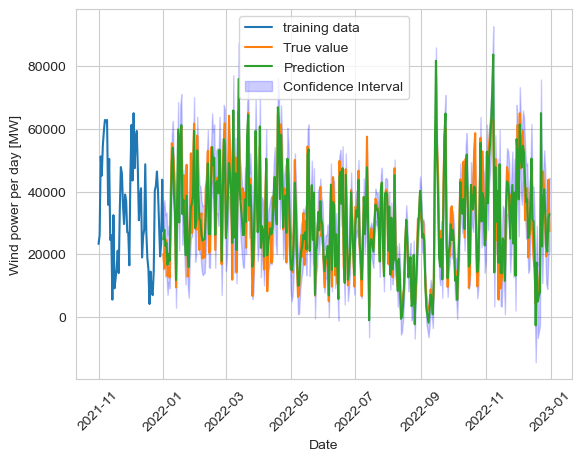

In [11]:
ap = ARIMAxPredictions()
ap.forecast_range(start_date='2022-01-01', end_date='2022-12-31')

Mean absolute percentage error:  0.18325177718435837
Mean absolute error:  4570.283356656233
r2 score:  0.847009674348123


(0.18325177718435837, 4570.283356656233, 0.847009674348123)

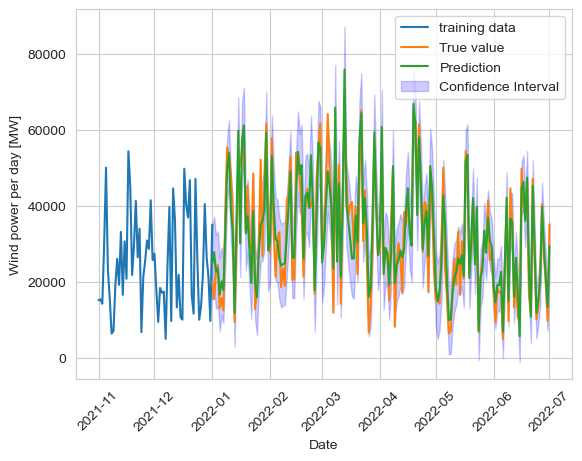

In [12]:
ap = ARIMAxPredictions()
ap.forecast_range(start_date='2022-01-01', end_date='2022-07-01')